# STAG 连续时序 Conv-SNN 训练 1

本 notebook 负责参数设置、数据集构建、训练过程、每轮测试评估、测试集早停、模型保存和结果可视化。底层函数均定义在清晰注释的 `.py` 文件中。

> **实验方法提醒**：按照当前要求，官方测试集每个 epoch 都参与评估，并用于早停和选择最佳模型。因此这里的测试集实际承担验证集角色，最高测试准确率存在模型选择偏倚，不是严格独立的最终泛化结果。该事实会写入 `config.json` 和 `summary.json`。

In [43]:
%matplotlib inline

from pathlib import Path
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from spikingjelly.activation_based import functional

CODE_DIR = next(
    path for path in (Path.cwd(), Path.cwd() / "code")
    if (path / "stag_data.py").is_file()
)
PROJECT_ROOT = CODE_DIR.parent
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

from snn_model import ConvSNNClassifier, count_trainable_parameters
from stag_data import (
    build_window_index,
    load_stag_metadata,
    save_class_mapping,
    summarize_window_index,
)
from stag_dataset import (
    STAGSequenceDataset,
    compute_class_weights,
    precompute_normalized_pressure,
)
from train_utils import (
    EarlyStopping,
    build_history_row,
    configure_cuda_performance,
    evaluate,
    load_checkpoint,
    prepare_output_directory,
    recommended_device,
    recommended_num_workers,
    save_checkpoint,
    save_history_csv,
    save_json,
    seed_worker,
    set_random_seed,
    train_one_epoch,
)
from visualization import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_prediction_examples,
    plot_tactile_sequence,
    plot_training_curves,
)

print(f"PyTorch：{torch.__version__}")
print(f"CUDA 可用：{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU：{torch.cuda.get_device_name(0)}")

PyTorch：2.8.0+cu128
CUDA 可用：True
GPU：NVIDIA RTX PRO 6000 Blackwell Server Edition


In [44]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Noto Sans CJK JP',
    'Noto Sans CJK SC',
    'WenQuanYi Zen Hei'
]

plt.rcParams['axes.unicode_minus'] = False

## 1. 全部实验参数

默认 `RUN_TRAINING=False`。保持该值时，notebook 只会读取真实数据并完成一个批次的模型前向检查，不会进入训练循环。

In [45]:
# ===== 安全开关 =====
RUN_TRAINING = True

# ===== 路径与复现 =====
ZIP_PATH = PROJECT_ROOT / "stag_data" / "classification_lite.zip"
OUTPUT_ROOT = CODE_DIR / "outputs"
EXPERIMENT_NAME = "conv_snn_interaction_l16_s8_64batchsize"
SEED = 42
DETERMINISTIC = False            # True 可严格复现，但卷积通常会变慢

# ===== 数据窗口 =====
WINDOW_SIZE = 16
STRIDE = 8
WINDOW_MODE = "interaction"       # 可改为 "stable"
MIN_VALID_RATIO = 0.75             # stable 模式会自动要求 1.0
BAD_PRESSURE_THRESHOLD = 950.0
GAP_FACTOR = 2.5
PRESSURE_MIN = 500.0
PRESSURE_MAX = 650.0

# ===== DataLoader =====
BATCH_SIZE = 64                  # 96 GB RTX PRO 6000 的保守起点，可继续试 512
NUM_WORKERS = recommended_num_workers(max_workers=8)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
PREFETCH_FACTOR = 4
PRECOMPUTE_NORMALIZED_PRESSURE = True

# ===== 模型与训练 =====
MODEL_CHANNELS = (16, 32, 64)
TAU = 2.0
MAX_EPOCHS = 120
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
EARLY_STOPPING_PATIENCE = 30
USE_CLASS_WEIGHTS = True
ALLOW_TF32 = True
PROGRESS_LOSS_INTERVAL = 0       # 避免逐 batch .item() 导致 CUDA 同步

DEVICE = recommended_device()
AMP_DTYPE = (
    torch.bfloat16
    if DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
    else None
)
FUSED_ADAMW = DEVICE.type == "cuda"
print(f"运行设备：{DEVICE}")
print(f"batch size / workers：{BATCH_SIZE} / {NUM_WORKERS}")
print(f"混合精度：{AMP_DTYPE or '关闭'}")
print(f"正式训练开关：{RUN_TRAINING}")

运行设备：cuda
batch size / workers：64 / 8
混合精度：torch.bfloat16
正式训练开关：True


## 2. 读取数据并构建窗口清单

窗口清单只保存索引，不复制重叠压力帧。过滤 `empty_hand` 后，原始 `objectId=1..26` 会映射成模型标签 `0..25`。

In [46]:
set_random_seed(SEED, deterministic=DETERMINISTIC)
configure_cuda_performance(
    DEVICE,
    deterministic=DETERMINISTIC,
    allow_tf32=ALLOW_TF32,
)
metadata = load_stag_metadata(ZIP_PATH)
window_index = build_window_index(
    metadata,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    mode=WINDOW_MODE,
    min_valid_ratio=MIN_VALID_RATIO,
    include_empty_hand=False,
    bad_pressure_threshold=BAD_PRESSURE_THRESHOLD,
    gap_factor=GAP_FACTOR,
)
train_manifest = window_index.split_manifest("train")
test_manifest = window_index.split_manifest("test")
class_names = window_index.class_names
num_classes = len(class_names)

display(summarize_window_index(window_index))
print(f"模型类别数：{num_classes}")
print(f"训练 recording：{train_manifest['recording_id'].nunique()}")
print(f"测试 recording：{test_manifest['recording_id'].nunique()}")
print(f"recording 是否无交集：{set(train_manifest['recording_id']).isdisjoint(set(test_manifest['recording_id']))}")

if WINDOW_MODE == "stable":
    missing_by_split = {
        split: sorted(set(range(num_classes)) - set(group["label"]))
        for split, group in window_index.manifest.groupby("split")
    }
    print(f"稳定模式各划分缺失标签：{missing_by_split}")

,split,windows,recordings,classes,mean_valid_ratio
0,train,4359,52,26,0.867186
1,test,2400,26,26,0.894479


模型类别数：26
训练 recording：52
测试 recording：26
recording 是否无交集：True


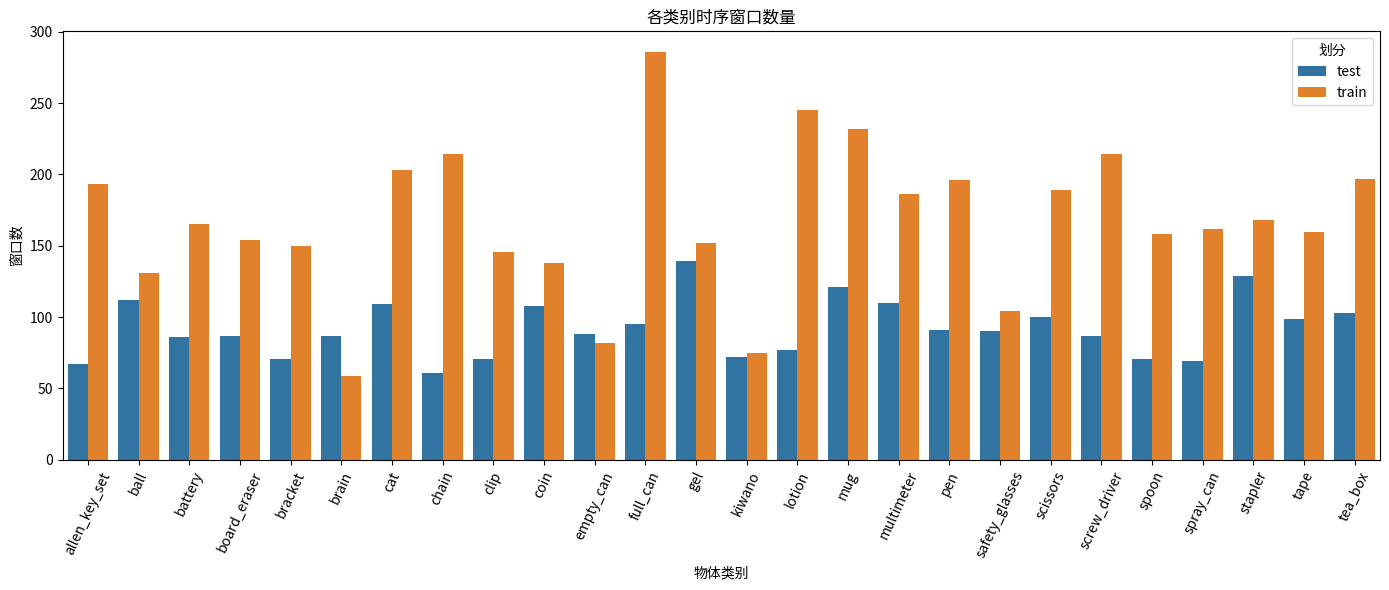

,split,split_id,batch_id,batch_name,recording_id,recording_name,start_offset,length,original_object_id,label,object_name,valid_ratio,start_frame,end_frame,start_timestamp,end_timestamp
0,train,0,1,001,28,028-mug,8,16,16,15,mug,0.750,8,23,1.089062,3.137179
1,train,0,1,001,28,028-mug,32,16,16,15,mug,0.875,32,47,4.363250,6.422367
2,train,0,1,001,28,028-mug,48,16,16,15,mug,0.750,48,63,6.558375,8.604492
3,train,0,1,001,28,028-mug,72,16,16,15,mug,0.750,72,87,9.830562,11.897681
4,train,0,1,001,28,028-mug,96,16,16,15,mug,1.000,96,111,13.124751,15.188869


In [47]:
plot_class_distribution(window_index.manifest, class_names)
plt.show()

display(train_manifest.head())

## 3. Dataset 与 DataLoader

模型收到的输入形状为 `[B, 16, 1, 32, 32]`。无效矩阵位置在归一化后会被掩码清零。

压力预归一化：0.52 GiB，耗时 0.40 s
x：(4, 16, 1, 32, 32), torch.float32
y：(4,), 范围 15~15
归一化范围：0.000~0.867


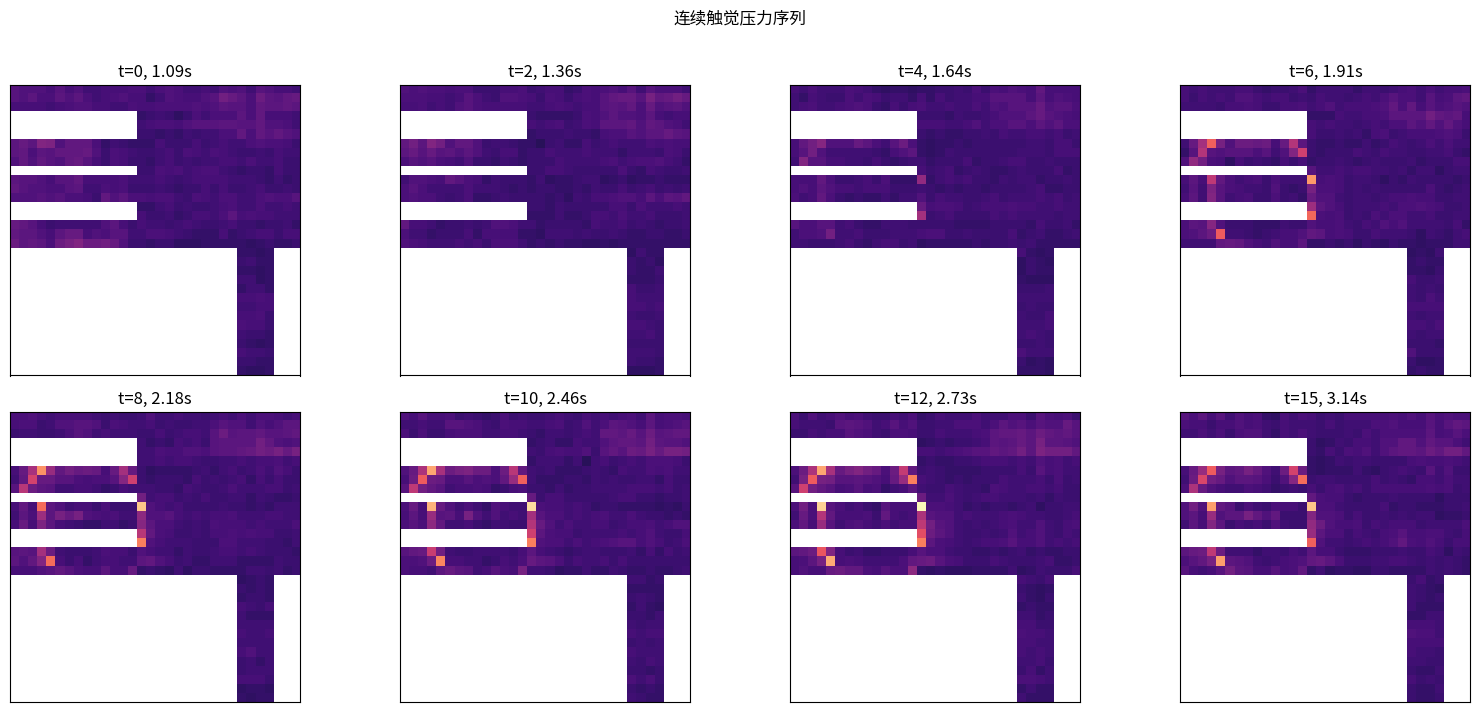

In [48]:
normalization_start = time.perf_counter()
normalized_pressure = (
    precompute_normalized_pressure(
        metadata,
        pressure_min=PRESSURE_MIN,
        pressure_max=PRESSURE_MAX,
    )
    if PRECOMPUTE_NORMALIZED_PRESSURE
    else None
)
if normalized_pressure is not None:
    print(
        f"压力预归一化：{normalized_pressure.nbytes / 2**30:.2f} GiB，"
        f"耗时 {time.perf_counter() - normalization_start:.2f} s"
    )

train_dataset = STAGSequenceDataset(
    metadata,
    train_manifest,
    window_index.recording_indices,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
    normalized_pressure=normalized_pressure,
    include_metadata=False,
)
test_dataset = STAGSequenceDataset(
    metadata,
    test_manifest,
    window_index.recording_indices,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
    normalized_pressure=normalized_pressure,
    include_metadata=False,
)

loader_worker_options = (
    {
        "persistent_workers": PERSISTENT_WORKERS,
        "prefetch_factor": PREFETCH_FACTOR,
    }
    if NUM_WORKERS > 0
    else {}
)
generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    generator=generator,
    **loader_worker_options,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    **loader_worker_options,
)

# 可视化预览保留时间戳等元数据，但不让这些字段进入训练热路径。
preview_dataset = STAGSequenceDataset(
    metadata,
    train_manifest.iloc[:4],
    window_index.recording_indices,
    pressure_min=PRESSURE_MIN,
    pressure_max=PRESSURE_MAX,
    normalized_pressure=normalized_pressure,
    include_metadata=True,
)
sample_batch = next(iter(DataLoader(preview_dataset, batch_size=4)))
print(f"x：{tuple(sample_batch['x'].shape)}, {sample_batch['x'].dtype}")
print(f"y：{tuple(sample_batch['y'].shape)}, 范围 {sample_batch['y'].min().item()}~{sample_batch['y'].max().item()}")
print(f"归一化范围：{sample_batch['x'].min().item():.3f}~{sample_batch['x'].max().item():.3f}")

plot_tactile_sequence(
    sample_batch["x"][0],
    timestamps=sample_batch["timestamps"][0],
    sensor_mask=metadata.sensor_mask,
)
plt.show()

## 4. 建立 Conv-SNN 并完成安全前向检查

这一节即使 `RUN_TRAINING=False` 也会运行，但不调用反向传播和优化器。检查后立即重置所有 LIF 膜电位。

In [49]:
model = ConvSNNClassifier(
    num_classes=num_classes,
    in_channels=1,
    channels=MODEL_CHANNELS,
    tau=TAU,
).to(DEVICE)

with torch.inference_mode():
    try:
        with torch.autocast(
            device_type=DEVICE.type,
            dtype=AMP_DTYPE,
            enabled=AMP_DTYPE is not None,
        ):
            smoke_logits = model(
                sample_batch["x"][:2].to(DEVICE, non_blocking=True)
            )
    finally:
        functional.reset_net(model)

print(model)
print(f"可训练参数量：{count_trainable_parameters(model):,}")
print(f"真实批次前向输出：{tuple(smoke_logits.shape)}")
assert tuple(smoke_logits.shape) == (2, num_classes)

ConvSNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=m)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, step_mode=m)
    (2): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=m)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False, step_mode=m)
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, step_mode=m)
    (6): LIFNode(
      v_threshold=1.0, v_reset=0.0, detach_reset=True, step_mode=m, backend=torch, tau=2.0
      (surrogate_function): ATan(alpha=2.0, spiking=True)
    )
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False, step_mode=m)
    (8): Con

## 5. 正式训练、每轮测试、早停与保存

只有把 `RUN_TRAINING` 改为 `True` 才会执行本节。最佳模型按测试准确率选择；准确率相同时选择测试损失更低的 epoch。

训练:   0%|          | 0/69 [00:00<?, ?it/s]

评估:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 001 | train loss=3.2131, acc=0.0911 | test loss=3.2226, acc=0.0638, macro-F1=0.0271 | 378 samples/s, 12.2 s （已保存最佳模型）


训练:   0%|          | 0/69 [00:00<?, ?it/s]

评估:   0%|          | 0/38 [00:00<?, ?it/s]

...

Epoch 076 | train loss=1.6325, acc=0.5930 | test loss=2.9096, acc=0.1492, macro-F1=0.1034 | 1238 samples/s, 4.0 s 


训练:   0%|          | 0/69 [00:00<?, ?it/s]

评估:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 077 | train loss=1.6248, acc=0.5926 | test loss=2.9273, acc=0.1471, macro-F1=0.1077 | 1250 samples/s, 3.9 s 
连续 30 个 epoch 未改进，提前停止。


评估:   0%|          | 0/38 [00:00<?, ?it/s]

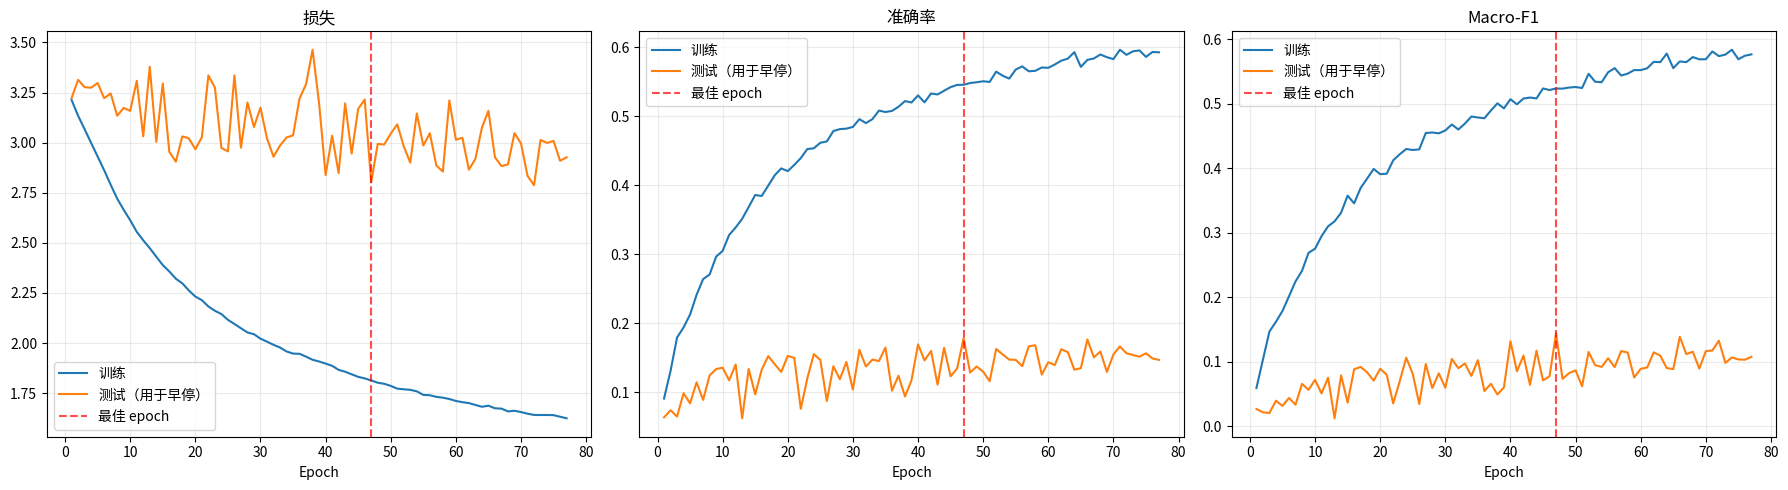

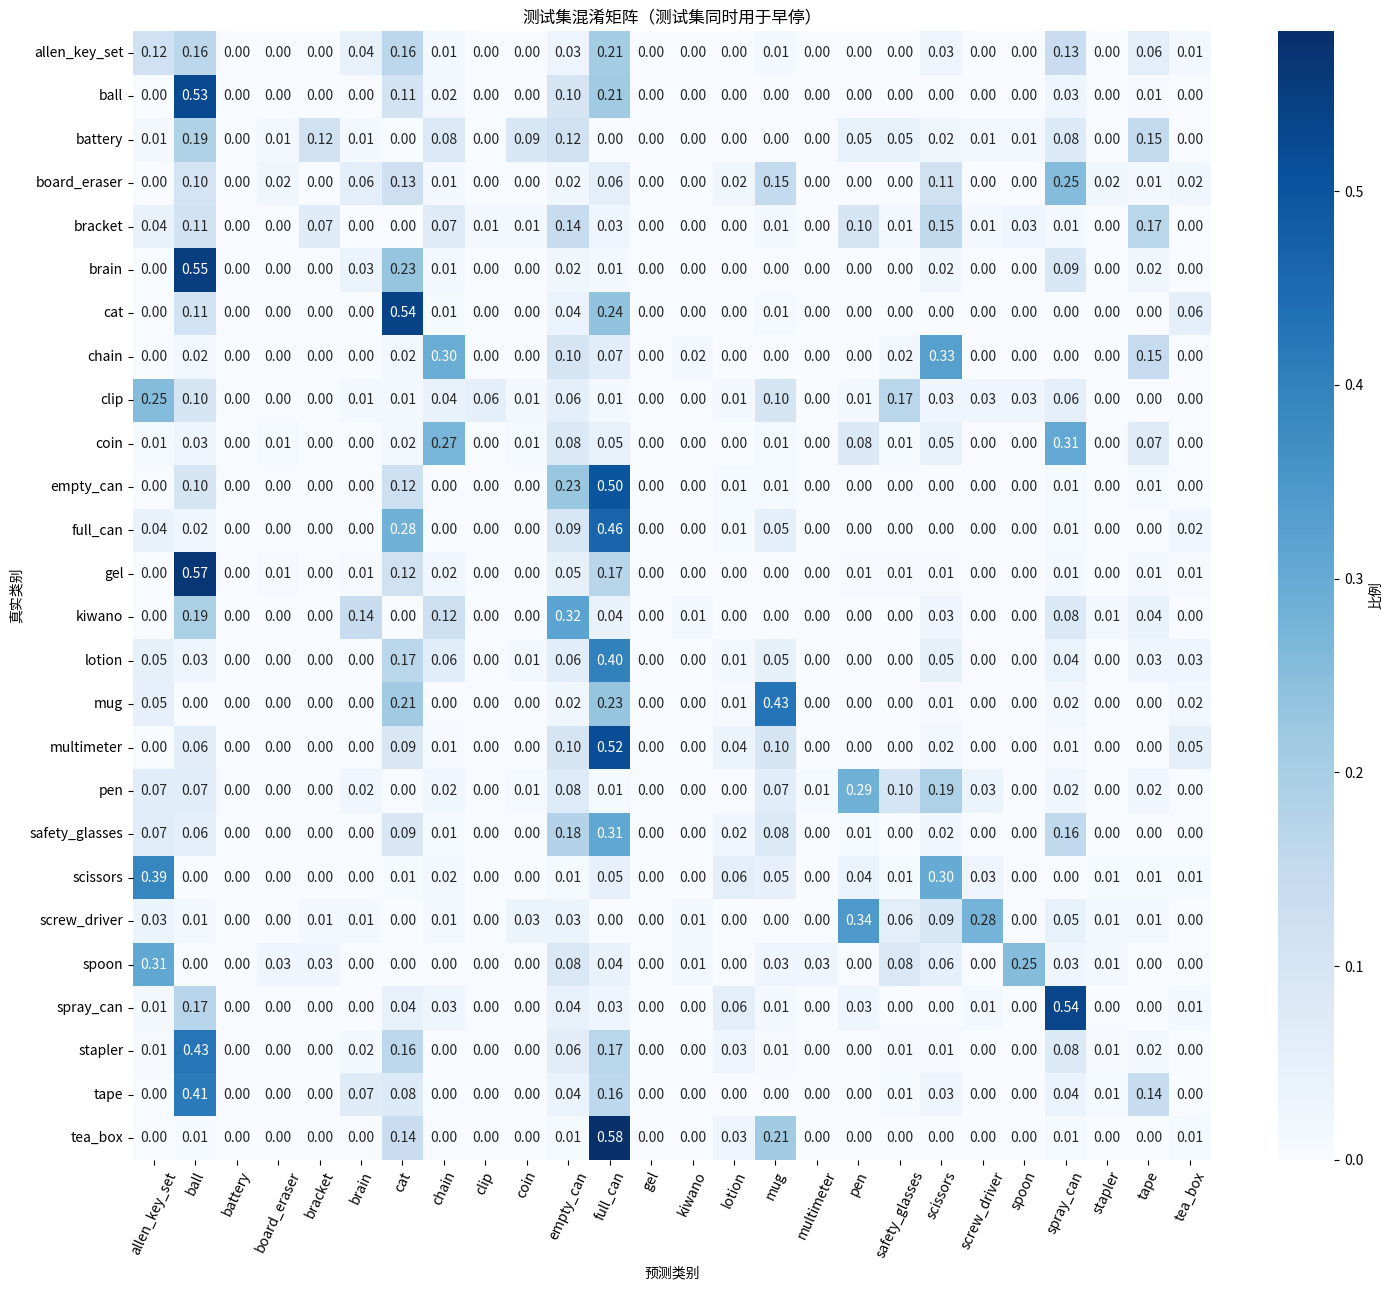

,best_epoch,best_test_loss,best_test_accuracy,best_test_macro_f1,epochs_completed,early_stopped,elapsed_seconds,mean_train_samples_per_second,train_windows,test_windows,test_set_used_for_early_stopping,methodological_warning
0,47,2.802321,0.178333,0.144145,77,True,309.278438,1250.104616,4359,2400,True,官方测试集每个 epoch 都参与早停和最佳模型选择，因此最终测试结果存在模型选择偏倚。


In [50]:
history = []
output_dir = None
best_test_result = None
training_finished = False

experiment_config = {
    "experiment_name": EXPERIMENT_NAME,
    "zip_path": str(ZIP_PATH),
    "seed": SEED,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "window_mode": WINDOW_MODE,
    "min_valid_ratio": MIN_VALID_RATIO,
    "bad_pressure_threshold": BAD_PRESSURE_THRESHOLD,
    "gap_factor": GAP_FACTOR,
    "pressure_min": PRESSURE_MIN,
    "pressure_max": PRESSURE_MAX,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "persistent_workers": PERSISTENT_WORKERS,
    "prefetch_factor": PREFETCH_FACTOR,
    "precompute_normalized_pressure": PRECOMPUTE_NORMALIZED_PRESSURE,
    "model_channels": list(MODEL_CHANNELS),
    "tau": TAU,
    "max_epochs": MAX_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "deterministic": DETERMINISTIC,
    "allow_tf32": ALLOW_TF32,
    "amp_dtype": str(AMP_DTYPE).removeprefix("torch.") if AMP_DTYPE else None,
    "fused_adamw": FUSED_ADAMW,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_metric": "test_accuracy",
    "tie_breaker": "lower_test_loss",
    "use_class_weights": USE_CLASS_WEIGHTS,
    "test_set_used_for_early_stopping": True,
    "methodological_warning": (
        "官方测试集每个 epoch 都参与早停和最佳模型选择，"
        "因此最终测试结果存在模型选择偏倚。"
    ),
}

if not RUN_TRAINING:
    print("RUN_TRAINING=False：已安全跳过正式训练、文件写入和 epoch 测试。")
else:
    output_dir = prepare_output_directory(OUTPUT_ROOT, EXPERIMENT_NAME)
    save_json(output_dir / "config.json", experiment_config)
    save_class_mapping(
        output_dir / "class_mapping.json",
        class_names,
        window_index.original_object_id_to_label,
    )
    train_manifest.to_csv(output_dir / "train_windows.csv", index=False, encoding="utf-8-sig")
    test_manifest.to_csv(output_dir / "test_windows.csv", index=False, encoding="utf-8-sig")

    class_weights = (
        compute_class_weights(train_manifest, num_classes).to(DEVICE)
        if USE_CLASS_WEIGHTS
        else None
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        fused=FUSED_ADAMW,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=MAX_EPOCHS,
    )
    early_stopping = EarlyStopping(patience=EARLY_STOPPING_PATIENCE)
    training_start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        epoch_start = time.perf_counter()
        train_start = time.perf_counter()
        train_result = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE,
            num_classes,
            grad_clip=GRAD_CLIP,
            amp_dtype=AMP_DTYPE,
            progress_loss_interval=PROGRESS_LOSS_INTERVAL,
        )
        train_seconds = time.perf_counter() - train_start
        # 按当前实验要求，官方测试集在每个 epoch 后用于模型选择。
        test_result = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE,
            num_classes,
            amp_dtype=AMP_DTYPE,
        )
        epoch_seconds = time.perf_counter() - epoch_start
        row = build_history_row(
            epoch,
            current_lr,
            train_result,
            test_result,
        )
        row.update(
            train_seconds=train_seconds,
            train_samples_per_second=train_result.sample_count / train_seconds,
            epoch_seconds=epoch_seconds,
        )
        history.append(row)
        improved, should_stop = early_stopping.step(
            test_result.accuracy,
            test_result.loss,
            epoch,
        )
        scheduler.step()

        save_checkpoint(
            output_dir / "last_model.pt",
            model,
            optimizer,
            scheduler,
            epoch,
            class_names,
            model.get_config(),
            row,
            early_stopping,
            experiment_config,
        )
        if improved:
            save_checkpoint(
                output_dir / "best_model.pt",
                model,
                optimizer,
                scheduler,
                epoch,
                class_names,
                model.get_config(),
                row,
                early_stopping,
                experiment_config,
            )
        save_history_csv(output_dir / "history.csv", history)

        marker = "（已保存最佳模型）" if improved else ""
        print(
            f"Epoch {epoch:03d} | "
            f"train loss={train_result.loss:.4f}, acc={train_result.accuracy:.4f} | "
            f"test loss={test_result.loss:.4f}, acc={test_result.accuracy:.4f}, "
            f"macro-F1={test_result.macro_f1:.4f} | "
            f"{row['train_samples_per_second']:.0f} samples/s, "
            f"{epoch_seconds:.1f} s {marker}"
        )
        if should_stop:
            print(f"连续 {EARLY_STOPPING_PATIENCE} 个 epoch 未改进，提前停止。")
            break

    checkpoint = load_checkpoint(
        output_dir / "best_model.pt",
        model,
        map_location=DEVICE,
    )
    best_test_result = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE,
        num_classes,
        amp_dtype=AMP_DTYPE,
    )
    elapsed_seconds = time.perf_counter() - training_start
    summary = {
        "best_epoch": checkpoint["epoch"],
        "best_test_loss": best_test_result.loss,
        "best_test_accuracy": best_test_result.accuracy,
        "best_test_macro_f1": best_test_result.macro_f1,
        "epochs_completed": len(history),
        "early_stopped": len(history) < MAX_EPOCHS,
        "elapsed_seconds": elapsed_seconds,
        "mean_train_samples_per_second": float(
            np.mean([row["train_samples_per_second"] for row in history])
        ),
        "train_windows": len(train_manifest),
        "test_windows": len(test_manifest),
        "test_set_used_for_early_stopping": True,
        "methodological_warning": experiment_config["methodological_warning"],
    }
    save_json(output_dir / "summary.json", summary)
    plot_training_curves(
        history,
        best_epoch=checkpoint["epoch"],
        save_path=output_dir / "training_curves.png",
    )
    plt.show()
    plot_confusion_matrix(
        best_test_result.confusion_matrix,
        class_names,
        normalize=True,
        save_path=output_dir / "confusion_matrix.png",
    )
    plt.show()
    display(pd.DataFrame([summary]))
    training_finished = True

## 6. 最佳模型预测示例

仅在正式训练完成后执行。展示每个窗口的中间触觉帧、真实类别和预测类别。

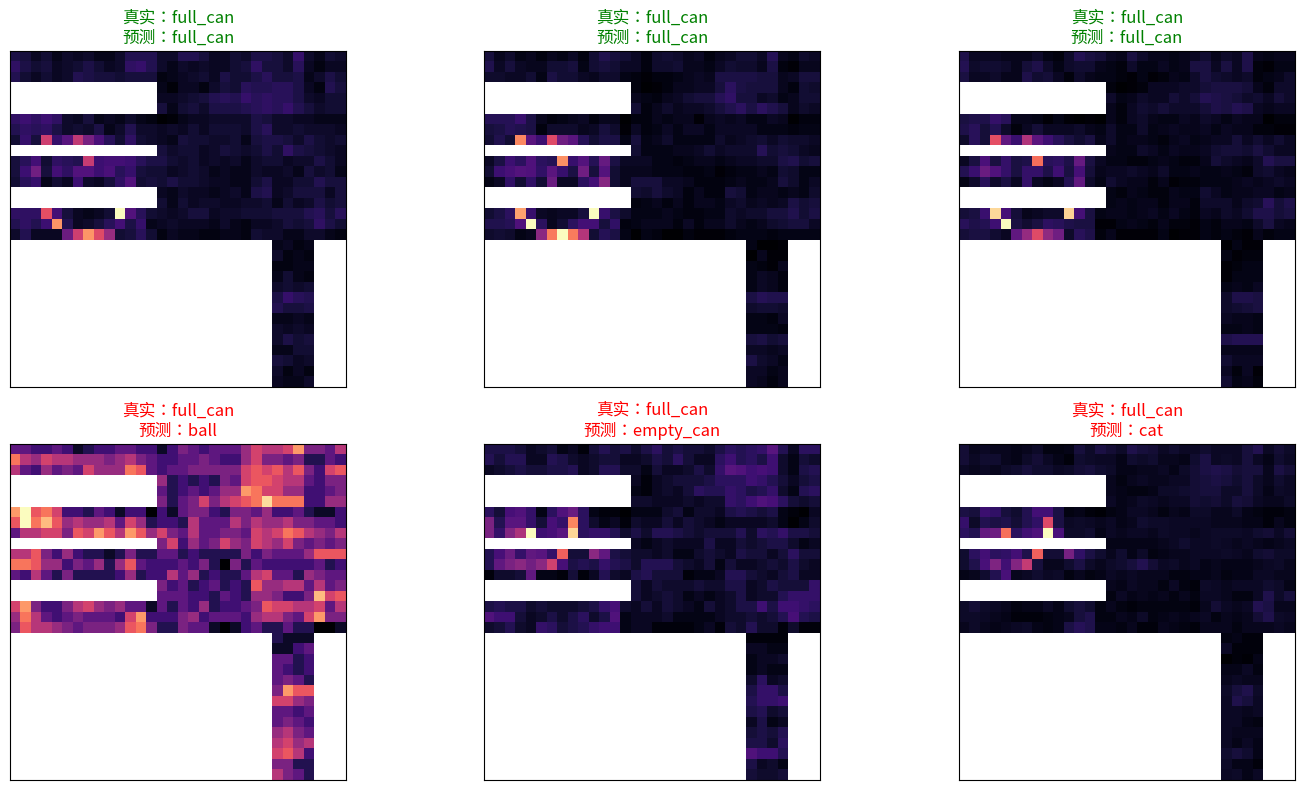

实验文件已保存到：/root/autodl-tmp/SNN_for_STAG/code/outputs/conv_snn_interaction_l16_s8_64batchsize


In [51]:
if not training_finished:
    print("尚未执行正式训练，因此没有最佳模型预测示例。")
else:
    prediction_batch = next(iter(test_loader))
    with torch.inference_mode():
        try:
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=AMP_DTYPE,
                enabled=AMP_DTYPE is not None,
            ):
                prediction_logits = model(
                    prediction_batch["x"].to(DEVICE, non_blocking=True)
                )
        finally:
            functional.reset_net(model)
    predictions = prediction_logits.argmax(dim=1).cpu().numpy()
    targets = prediction_batch["y"].numpy()
    plot_prediction_examples(
        prediction_batch["x"],
        targets,
        predictions,
        class_names,
        metadata.sensor_mask,
    )
    plt.show()
    print(f"实验文件已保存到：{output_dir}")